# Лабораторная работа 5

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук — заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm — если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста — не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [ ]:
pre_intro = """
1. Переобучение это когда модель слишком хорошо запомнила обучающие данные,
включая их шум и случайности. На train точность высокая, а на новых данных
модель ошибается, потому что не выучила общие закономерности, а просто
выучила конкретные примеры наизусть.

2. Даже если модель "хорошо обучается", она может делать это неправильно,
например, полагаться на несколько сильных признаков и игнорировать остальные,
или подстраиваться под шум в данных. Регуляризация мешает этому,
заставляя модель находить более простые и устойчивые решения.

3.
- L2 штрафует большие веса — если вес слишком большой, модель платит за это
  в функции потерь. Это не даёт отдельным нейронам доминировать.
- Dropout случайно отключает часть нейронов при каждом шаге обучения.
  Сеть не может полагаться на один путь — учится распределять знания.
- BatchNorm нормализует данные внутри сети между слоями, чтобы значения
  не "разъезжались" в процессе обучения. Это делает обучение стабильнее
  и быстрее.
"""
print(pre_intro)


1. Переобучение это когда модель слишком хорошо запомнила обучающие данные,
включая их шум и случайности. На train точность высокая, а на новых данных
модель ошибается, потому что не выучила общие закономерности, а просто
выучила конкретные примеры наизусть.

2. Даже если модель "хорошо обучается", она может делать это неправильно,
например, полагаться на несколько сильных признаков и игнорировать остальные,
или подстраиваться под шум в данных. Регуляризация мешает этому,
заставляя модель находить более простые и устойчивые решения.

3. 
- L2 штрафует большие веса — если вес слишком большой, модель платит за это
  в функции потерь. Это не даёт отдельным нейронам доминировать.
- Dropout случайно отключает часть нейронов при каждом шаге обучения.
  Сеть не может полагаться на один путь — учится распределять знания.
- BatchNorm нормализует данные внутри сети между слоями, чтобы значения
  не "разъезжались" в процессе обучения. Это делает обучение стабильнее
  и быстрее.



## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 7
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 7


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [6]:
batch_size = 64  #TODO: Попробуйте несколько значений. Запишите, как меняется время эпохи и шумность loss-кривой в зависимости от размера батча

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]

train size = 60000
test size  = 10000
batch_size = 64


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


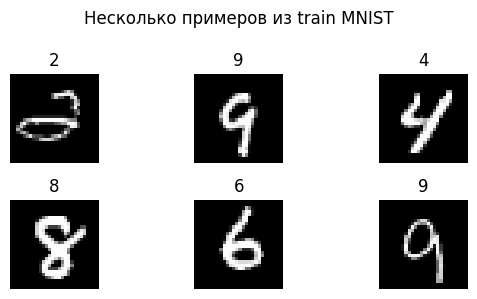

In [7]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» — это просто ваши наблюдения.

In [8]:
data_impression = """
Большинство цифр читаются хорошо - чёрный фон, белые чёткие линии.
Сомнения могут вызвать написанные наклонно или с нестандартным стилем цифры.
Визуально похожи пары 4 и 9 (закрытый верх), 3 и 8 (похожие округлые формы),
1 и 7 (вертикальная черта). Думаю, модель будет чаще ошибаться именно на них.
Данные выглядят чистыми - явного шума или нечитаемых примеров не заметила.
"""
print(data_impression)


Большинство цифр читаются хорошо - чёрный фон, белые чёткие линии.
Сомнения могут вызвать написанные наклонно или с нестандартным стилем цифры.
Визуально похожи пары 4 и 9 (закрытый верх), 3 и 8 (похожие округлые формы),
1 и 7 (вертикальная черта). Думаю, модель будет чаще ошибаться именно на них.
Данные выглядят чистыми - явного шума или нечитаемых примеров не заметила.



## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** — без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** — тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** — тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [9]:
class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=0.3):  # p=0.3 вместо 0.5 — не слишком агрессивно
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(p=p),  # отключает 30% нейронов случайно при каждом шаге train
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=p),  # тот же p для единообразия — оба слоя одинаково "ненадёжны"
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),  # нормализует 512 признаков по батчу из 128 примеров
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(BaseMLP())
print(DropoutMLP())
print(BatchNormMLP())

BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)
BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): B

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` — один проход по train;
- `evaluate` — оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование — делайте это здесь и прокомментируйте в отчёте.


In [10]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total


def evaluate(model, dataloader, criterion, device, verbose=False):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0
    class_correct = torch.zeros(10)
    class_total   = torch.zeros(10)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

            for c in range(10):
                mask = (labels == c)
                class_correct[c] += (preds[mask] == labels[mask]).sum().item()
                class_total[c]   += mask.sum().item()

    if verbose:
        class_acc = class_correct / class_total
        worst = class_acc.argsort()[:3]
        print(f"  Хуже всего: цифры {worst.tolist()} "
              f"с точностью {class_acc[worst].tolist()}")

    return running_loss / total, running_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [11]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.3,
                   num_epochs=10, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model, history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` — BaseMLP, `weight_decay=0`.  
2. `Base / L2` — BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` — DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` — BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [12]:
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0,
    num_epochs=10,
    lr=1e-3
)


=== Конфигурация: Base / no_reg ===
Эпоха 1/10 | train_loss=0.2043, train_acc=0.9375, test_loss=0.1277, test_acc=0.9601
Эпоха 2/10 | train_loss=0.0871, train_acc=0.9724, test_loss=0.1038, test_acc=0.9687
Эпоха 3/10 | train_loss=0.0592, train_acc=0.9811, test_loss=0.1034, test_acc=0.9715
Эпоха 4/10 | train_loss=0.0472, train_acc=0.9849, test_loss=0.0831, test_acc=0.9749
Эпоха 5/10 | train_loss=0.0370, train_acc=0.9879, test_loss=0.0894, test_acc=0.9751
Эпоха 6/10 | train_loss=0.0298, train_acc=0.9902, test_loss=0.0799, test_acc=0.9779
Эпоха 7/10 | train_loss=0.0296, train_acc=0.9903, test_loss=0.1017, test_acc=0.9719
Эпоха 8/10 | train_loss=0.0246, train_acc=0.9923, test_loss=0.0833, test_acc=0.9783
Эпоха 9/10 | train_loss=0.0223, train_acc=0.9929, test_loss=0.0799, test_acc=0.9805
Эпоха 10/10 | train_loss=0.0206, train_acc=0.9936, test_loss=0.0782, test_acc=0.9801


In [14]:
l2_model, l2_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / L2 (wd=1e-4)",
    weight_decay=1e-4,  # 1e-2 слишком сильно штрафует, 1e-6 почти не заметно
    num_epochs=10,
    lr=1e-3
)


=== Конфигурация: Base / L2 (wd=1e-4) ===
Эпоха 1/10 | train_loss=0.2043, train_acc=0.9368, test_loss=0.1209, test_acc=0.9625
Эпоха 2/10 | train_loss=0.0866, train_acc=0.9730, test_loss=0.0816, test_acc=0.9741
Эпоха 3/10 | train_loss=0.0644, train_acc=0.9800, test_loss=0.0742, test_acc=0.9758
Эпоха 4/10 | train_loss=0.0513, train_acc=0.9830, test_loss=0.1008, test_acc=0.9690
Эпоха 5/10 | train_loss=0.0453, train_acc=0.9851, test_loss=0.0858, test_acc=0.9750
Эпоха 6/10 | train_loss=0.0375, train_acc=0.9879, test_loss=0.0799, test_acc=0.9754
Эпоха 7/10 | train_loss=0.0351, train_acc=0.9885, test_loss=0.0700, test_acc=0.9802
Эпоха 8/10 | train_loss=0.0306, train_acc=0.9898, test_loss=0.0901, test_acc=0.9757
Эпоха 9/10 | train_loss=0.0307, train_acc=0.9893, test_loss=0.0780, test_acc=0.9798
Эпоха 10/10 | train_loss=0.0247, train_acc=0.9913, test_loss=0.0980, test_acc=0.9735


In [15]:
drop_model, drop_hist = run_experiment(
    model_class=DropoutMLP,
    config_name="Dropout p=0.3",
    dropout_p=0.3,  # наш p из архитектуры, не 0.5
    weight_decay=0.0,
    num_epochs=10,
    lr=1e-3
)


=== Конфигурация: Dropout p=0.3 ===
Эпоха 1/10 | train_loss=0.2596, train_acc=0.9185, test_loss=0.1137, test_acc=0.9641
Эпоха 2/10 | train_loss=0.1300, train_acc=0.9603, test_loss=0.0873, test_acc=0.9720
Эпоха 3/10 | train_loss=0.1043, train_acc=0.9681, test_loss=0.0714, test_acc=0.9780
Эпоха 4/10 | train_loss=0.0892, train_acc=0.9727, test_loss=0.0732, test_acc=0.9778
Эпоха 5/10 | train_loss=0.0804, train_acc=0.9754, test_loss=0.0680, test_acc=0.9808
Эпоха 6/10 | train_loss=0.0727, train_acc=0.9783, test_loss=0.0797, test_acc=0.9750
Эпоха 7/10 | train_loss=0.0682, train_acc=0.9794, test_loss=0.0749, test_acc=0.9789
Эпоха 8/10 | train_loss=0.0639, train_acc=0.9798, test_loss=0.0855, test_acc=0.9770
Эпоха 9/10 | train_loss=0.0605, train_acc=0.9809, test_loss=0.0785, test_acc=0.9811
Эпоха 10/10 | train_loss=0.0542, train_acc=0.9833, test_loss=0.0668, test_acc=0.9825


In [18]:
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=10,
    lr=1e-3
)


=== Конфигурация: BatchNorm ===
Эпоха 1/10 | train_loss=0.1815, train_acc=0.9463, test_loss=0.0866, test_acc=0.9733
Эпоха 2/10 | train_loss=0.0786, train_acc=0.9757, test_loss=0.0717, test_acc=0.9775
Эпоха 3/10 | train_loss=0.0562, train_acc=0.9818, test_loss=0.0695, test_acc=0.9764
Эпоха 4/10 | train_loss=0.0418, train_acc=0.9862, test_loss=0.0652, test_acc=0.9799
Эпоха 5/10 | train_loss=0.0339, train_acc=0.9891, test_loss=0.0643, test_acc=0.9804
Эпоха 6/10 | train_loss=0.0287, train_acc=0.9902, test_loss=0.0630, test_acc=0.9804
Эпоха 7/10 | train_loss=0.0230, train_acc=0.9921, test_loss=0.0639, test_acc=0.9813
Эпоха 8/10 | train_loss=0.0203, train_acc=0.9930, test_loss=0.0564, test_acc=0.9825
Эпоха 9/10 | train_loss=0.0193, train_acc=0.9931, test_loss=0.0705, test_acc=0.9813
Эпоха 10/10 | train_loss=0.0167, train_acc=0.9943, test_loss=0.0778, test_acc=0.9780


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов:
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


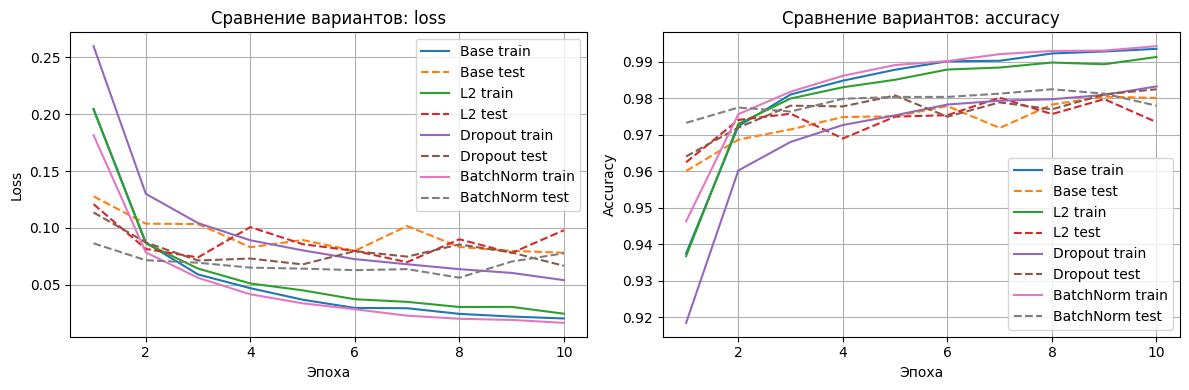

In [19]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[base_hist, l2_hist, drop_hist, bn_hist],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение вариантов: "
)

## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) — это тоже часть обучения.


In [20]:
analysis_comment = """
Базовая модель показала нарастающий разрыв между train и test - к 10-й эпохе
train_acc=0.9936 против test_acc=0.9801, разрыв 0.0135. На графике loss видно
как train loss продолжает падать, а test loss колеблется и не улучшается после
6-й эпохи — признак начала переобучения.

L2 не помог, разрыв стал даже больше (0.0178), а финальный
test_acc=0.9735 хуже чем у базовой модели. На графике L2 test loss скачет
сильнее остальных. Возможно weight_decay=1e-4 оказался слишком слабым для
этой архитектуры, а более сильный 1e-2 просто мешал обучению.

Dropout вёл себя интереснее всего. В начале train loss был выше остальных
(0.26 на первой эпохе против 0.20 у базовой), но зато разрыв между train и
test оказался минимальным: 0.0008. Это именно то чего ожидаешь от регуляризации
- не максимальная точность на train, а лучшая генерализация.

BatchNorm сходился быстрее всех - уже к первой эпохе test_acc=0.973, тогда
как Base давала 0.960. Кривые действительно ровнее, без резких скачков.
Но к концу обучения train и test разошлись сильнее чем у Dropout.

Если выбирать одну технику для этой задачи — выбрала бы Dropout p=0.3.
Он дал наименьший разрыв train/test и лучший финальный test_acc=0.9825,
при этом не замедлил обучение критично. BatchNorm хорош если важна скорость
сходимости, но по итогу генерализирует хуже.
"""
print(analysis_comment)


Базовая модель показала нарастающий разрыв между train и test - к 10-й эпохе
train_acc=0.9936 против test_acc=0.9801, разрыв 0.0135. На графике loss видно
как train loss продолжает падать, а test loss колеблется и не улучшается после
6-й эпохи — признак начала переобучения.

L2 не помог, разрыв стал даже больше (0.0178), а финальный
test_acc=0.9735 хуже чем у базовой модели. На графике L2 test loss скачет
сильнее остальных. Возможно weight_decay=1e-4 оказался слишком слабым для
этой архитектуры, а более сильный 1e-2 просто мешал обучению.

Dropout вёл себя интереснее всего. В начале train loss был выше остальных
(0.26 на первой эпохе против 0.20 у базовой), но зато разрыв между train и
test оказался минимальным: 0.0008. Это именно то чего ожидаешь от регуляризации
- не максимальная точность на train, а лучшая генерализация.

BatchNorm сходился быстрее всех - уже к первой эпохе test_acc=0.973, тогда
как Base давала 0.960. Кривые действительно ровнее, без резких скачков.
Но к концу обуч

## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm — именно на примере **ваших** экспериментов, а не абстрактной теории.


In [21]:
final_summary = """
Лучшей конфигурацией для этой задачи считаю DropoutMLP с p=0.3, lr=1e-3,
10 эпох, batch_size=128. Она дала наименьший разрыв train/test (0.0008)
и лучший test_acc=0.9825 — то есть модель не просто запомнила train,
а научилась обобщать.

Ожидания частично не совпали: думала что L2 поможет стабилизировать обучение,
но на практике разрыв с L2 оказался даже больше чем без него. Возможно нужно
было подбирать weight_decay тщательнее, или MNIST просто слишком простой
датасет чтобы L2 дал заметный эффект.

BatchNorm удивил скоростью сходимости, не думала что
разница будет такой заметной уже на первой эпохе.

L2 стоит пробовать когда веса уходят в большие значения и модель явно
переподгоняется — но нужно аккуратно подбирать коэффициент.
Dropout хорош когда важна генерализация и не хочется усложнять
архитектуру, он просто заставляет сеть не полагаться на отдельные нейроны.
BatchNorm выбирай когда важна скорость обучения или данные плохо
масштабированы между слоями.
"""
print(final_summary)


Лучшей конфигурацией для этой задачи считаю DropoutMLP с p=0.3, lr=1e-3,
10 эпох, batch_size=128. Она дала наименьший разрыв train/test (0.0008)
и лучший test_acc=0.9825 — то есть модель не просто запомнила train,
а научилась обобщать.

Ожидания частично не совпали: думала что L2 поможет стабилизировать обучение,
но на практике разрыв с L2 оказался даже больше чем без него. Возможно нужно
было подбирать weight_decay тщательнее, или MNIST просто слишком простой
датасет чтобы L2 дал заметный эффект.

BatchNorm удивил скоростью сходимости, не думала что
разница будет такой заметной уже на первой эпохе.

L2 стоит пробовать когда веса уходят в большие значения и модель явно 
переподгоняется — но нужно аккуратно подбирать коэффициент. 
Dropout хорош когда важна генерализация и не хочется усложнять
архитектуру, он просто заставляет сеть не полагаться на отдельные нейроны.
BatchNorm выбирай когда важна скорость обучения или данные плохо
масштабированы между слоями.

